In [ ]:
# Dashboard — DL Baseline Comparison

Dashboard này dùng cho phần **Person 2 (Deep Learning)**.

- Nhập câu để dự đoán bằng các mô hình **LSTM / BiLSTM / GRU** (nếu đã có weights).
- So sánh metrics tổng quan từ `results/` (Accuracy/Precision/Recall/Macro‑F1).

Nếu bảng/biểu đồ trống, hãy chạy `notebooks/02_dl_baseline.ipynb` để sinh lại `results/dl_baseline.csv` và các hình ảnh.

Components: ['SVM', 'BiLSTM', 'PhoBERT']
Weights   : {'SVM': np.float64(0.3333), 'BiLSTM': np.float64(0.3333), 'PhoBERT': np.float64(0.3333)}


<>:52: SyntaxWarning: invalid escape sequence '\]'
<>:52: SyntaxWarning: invalid escape sequence '\]'
C:\Users\vohongduc\AppData\Local\Temp\ipykernel_7108\1669829918.py:52: SyntaxWarning: invalid escape sequence '\]'
  _PUNCT = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’–—…•·«»\u200b"""


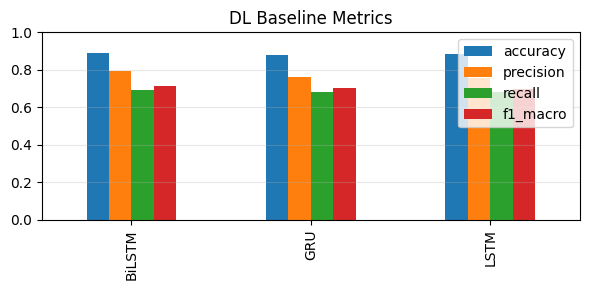

In [1]:
# --- DL baseline comparison (Person 2) --------------------------------------
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from underthesea import word_tokenize

ROOT = Path('..').resolve()
RESULTS = ROOT / 'results'
MODELS = ROOT / 'models'

DL_RESULTS_PATH = RESULTS / 'dl_baseline.csv'
DL_CURVES_PATH = RESULTS / 'dl_curves.png'
DL_CM_PATH = RESULTS / 'dl_confusion_matrix.png'
VOCAB_PATH = MODELS / 'dl_baseline_vocab.json'
WEIGHTS_PATH = MODELS / 'dl_baseline.pt'

LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_dl_results():
    if DL_RESULTS_PATH.exists():
        return pd.read_csv(DL_RESULTS_PATH)
    return pd.DataFrame(columns=['model', 'accuracy', 'precision', 'recall', 'f1_macro'])

def plot_dl_metrics(df):
    if df.empty:
        return None
    metrics = ['accuracy', 'precision', 'recall', 'f1_macro']
    df_plot = df.set_index('model')[metrics]
    ax = df_plot.plot(kind='bar', figsize=(6, 3), ylim=(0, 1), title='DL Baseline Metrics')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    fig = ax.get_figure()
    fig.tight_layout()
    return fig

def load_dl_dashboard():
    df = load_dl_results()
    fig = plot_dl_metrics(df)
    curves = str(DL_CURVES_PATH) if DL_CURVES_PATH.exists() else None
    cm = str(DL_CM_PATH) if DL_CM_PATH.exists() else None
    return df, fig, curves, cm

DL_DF, DL_FIG, DL_CURVES, DL_CM = load_dl_dashboard()

# --- Preprocess (lightweight, matching notebook 00/02) -----------------------
_PUNCT = """!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~“”‘’–—…•·«»\u200b"""
def preprocess(text: str) -> str:
    t = str(text).lower()
    t = ''.join(ch for ch in t if ch not in _PUNCT)
    t = ' '.join(t.split())
    t = word_tokenize(t, format='text')
    return t

# --- Model definition (must match notebook 02) -------------------------------
class RNNClassifier(nn.Module):
    def __init__(self, vocab, embed=128, hidden=128, n_classes=3,
                 rnn_type='lstm', bidir=False, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab, embed, padding_idx=0)
        rnn_cls = {'lstm': nn.LSTM, 'gru': nn.GRU}[rnn_type]
        self.rnn = rnn_cls(embed, hidden, batch_first=True, bidirectional=bidir)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * (2 if bidir else 1), n_classes)
    def forward(self, x):
        mask = (x != 0).unsqueeze(-1).float()
        h = self.emb(x)
        out, _ = self.rnn(h)
        pooled = (out * mask).sum(1) / mask.sum(1).clamp(min=1)
        return self.fc(self.dropout(pooled))

def load_vocab():
    if not VOCAB_PATH.exists():
        return None
    with open(VOCAB_PATH, 'r', encoding='utf-8') as f:
        return json.load(f)

def build_models(vocab_meta):
    if vocab_meta is None or not WEIGHTS_PATH.exists():
        return {}
    word2idx = vocab_meta['word2idx']
    max_len = vocab_meta['max_len']
    embed_dim = vocab_meta['embed_dim']
    hidden = vocab_meta['hidden']
    dropout = vocab_meta['dropout']
    num_classes = vocab_meta['num_classes']
    state = torch.load(WEIGHTS_PATH, map_location=DEVICE)

    models = {}
    for name, cfg in {
        'LSTM': {'rnn_type': 'lstm', 'bidir': False},
        'GRU': {'rnn_type': 'gru', 'bidir': False},
        'BiLSTM': {'rnn_type': 'lstm', 'bidir': True},
    }.items():
        model = RNNClassifier(
            vocab=len(word2idx),
            embed=embed_dim,
            hidden=hidden,
            n_classes=num_classes,
            dropout=dropout,
            rnn_type=cfg['rnn_type'],
            bidir=cfg['bidir'],
        ).to(DEVICE)
        try:
            model.load_state_dict(state, strict=False)
        except Exception:
            pass
        model.eval()
        models[name] = model
    return models, word2idx, max_len

def encode(text, word2idx, max_len):
    ids = [word2idx.get(w, word2idx.get('<unk>', 1)) for w in text.split()][:max_len]
    return ids + [0] * (max_len - len(ids))

VOCAB_META = load_vocab()
MODEL_BUNDLE = build_models(VOCAB_META) if VOCAB_META else ({}, {}, 0)
MODELS_MAP, WORD2IDX, MAX_LEN = MODEL_BUNDLE if isinstance(MODEL_BUNDLE, tuple) else ({}, {}, 0)

def predict_all(text: str):
    if not text or not text.strip():
        return 'Vui lòng nhập câu.', pd.DataFrame(), {}
    if not MODELS_MAP:
        return 'Chưa có weights. Hãy chạy notebook 02 trước.', pd.DataFrame(), {}
    clean = preprocess(text)
    x = torch.tensor([encode(clean, WORD2IDX, MAX_LEN)], dtype=torch.long).to(DEVICE)

    rows = []
    prob_dict = {}
    for name, model in MODELS_MAP.items():
        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        pred = int(probs.argmax())
        rows.append({
            'model': name,
            'prediction': LABEL_NAMES[pred],
            'prob_neg': float(probs[0]),
            'prob_neu': float(probs[1]),
            'prob_pos': float(probs[2]),
        })
        prob_dict[name] = {
            'Negative': float(probs[0]),
            'Neutral': float(probs[1]),
            'Positive': float(probs[2]),
        }
    df = pd.DataFrame(rows).sort_values('model')
    summary = f"Dự đoán xong cho {len(rows)} model."
    return summary, df, prob_dict

In [2]:
import gradio as gr

# Ensure data is loaded even if cells above weren't run
try:
    DL_DF, DL_FIG, DL_CURVES, DL_CM
except NameError:
    DL_DF, DL_FIG, DL_CURVES, DL_CM = load_dl_dashboard()

with gr.Blocks(title='DL Baseline Comparison', theme=gr.themes.Soft()) as demo:
    gr.Markdown('# So sánh Deep Learning Baseline (Person 2)')
    gr.Markdown(
        'Nguồn dữ liệu: `results/dl_baseline.csv`, `results/dl_curves.png`, '
        '`results/dl_confusion_matrix.png`.'
    )

    with gr.Tab('Dự đoán từng model'):
        inp = gr.Textbox(
            label='Nhập câu tiếng Việt',
            lines=3,
            placeholder='Ví dụ: Giảng viên dạy rất dễ hiểu và nhiệt tình',
        )
        btn = gr.Button('Dự đoán', variant='primary')
        out_status = gr.Textbox(label='Trạng thái', interactive=False)
        out_table = gr.Dataframe(
            label='Kết quả theo model (probabilities)',
            interactive=False,
            wrap=True,
        )
        out_json = gr.JSON(label='Xác suất chi tiết từng model')
        btn.click(predict_all, inputs=inp, outputs=[out_status, out_table, out_json])
        inp.submit(predict_all, inputs=inp, outputs=[out_status, out_table, out_json])

    with gr.Tab('So sánh metrics tổng quan'):
        dl_refresh = gr.Button('Reload kết quả', variant='secondary')
        dl_table = gr.Dataframe(
            value=DL_DF, label='Bảng so sánh metrics',
            interactive=False, wrap=True,
        )
        dl_plot = gr.Plot(value=DL_FIG, label='So sánh Accuracy/Precision/Recall/F1')
        with gr.Row():
            dl_curves = gr.Image(value=DL_CURVES, label='Training curves (dev)')
            dl_cm = gr.Image(value=DL_CM, label='Confusion matrix (best model)')

        dl_refresh.click(
            load_dl_dashboard,
            outputs=[dl_table, dl_plot, dl_curves, dl_cm],
        )

# share=False để chạy local; đổi share=True nếu cần link tạm public.
# inbrowser=True tự mở browser mặc định khi launch.
demo.launch(share=False, inbrowser=True)

C:\Users\vohongduc\AppData\Local\Temp\ipykernel_7108\4149638307.py:9: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title='DL Baseline Comparison', theme=gr.themes.Soft()) as demo:


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
* To create a public link, set `share=True` in `launch()`.
